# Calculating linear and rank correlations of fitness and $R_v(t)$

In [1]:
import glob
import os
import yaml # might not need
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, entropy
import warnings
from pandas.tseries.offsets import Day, BDay
from typing import Dict, Union, List, Tuple, Optional, Any

# Plotting tools
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import seaborn as sns

font = {'family' : 'sans-serif',
        'serif': 'Helvetica Neue',
        'weight' : 'light',
        'size'   : 20}

matplotlib.rc('font', **font)

# Mute warnings
warnings.filterwarnings('ignore')

# High-quality font settings
plt.rcParams.update({
    # Use serif fonts for main text elements
    'font.family': 'sans-serif',
    # Specifically use the TeX Gyre Pagella font or similar
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Computer Modern Roman'],
    # Set sizes appropriate for scientific publications
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    # Use LaTeX rendering for mathematical expressions and text
    'text.usetex': False,
    # Make sure the lines are thick enough to be visible in print
    'axes.linewidth': 0.8,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.8,
    # Use better DPI for export
    'savefig.dpi': 300,
    'figure.dpi': 150,
})

## Helper functions

In [2]:
def subset_fitness_df(rt_df : pd.DataFrame, fitness_df : pd.DataFrame) -> pd.DataFrame:
    """
    Subset the fitness df to only include the dates and variants in the rt_df

    Parameters
    ----------
    rt_df : pd.DataFrame
        Dataframe containing the rt estimates
    fitness_df : pd.DataFrame
        Dataframe containing the fitness estimates

    Returns
    -------
    fitness_subset_df : pd.DataFrame
        The subset fitness df with appropriate dates and variants.
    """
    min_date = rt_df['date'].min()
    max_date = rt_df['date'].max()
    variants = rt_df["variant"].unique()
    location = rt_df["location"].unique()[0]

    # Subset pruned fitness df to only include dates in the rt_df
    fitness_subset_df = fitness_df.query("date >= @min_date & date <= @max_date & location == @location & variant in @variants")
    
    return fitness_subset_df

In [3]:
def is_variant_flat(
    rt_values: Union[np.ndarray, pd.Series, List[float]], 
    fitness_values: Union[np.ndarray, pd.Series, List[float]],
    flat_threshold: float = 0.01
) -> bool:
    """
    Check if both Rt and fitness time series are flat based on their standard deviations.
    
    Parameters:
    -----------
    rt_values : array-like
        The Rt (reproductive number) values over time
    fitness_values : array-like
        The fitness values over time
    flat_threshold : float, optional (default=0.01)
        Threshold for standard deviation below which a line is considered flat
        
    Returns:
    --------
    bool
        True if both series are flat (std < flat_threshold), False otherwise
    """
    # Convert inputs to numpy arrays if they aren't already
    rt_array = np.asarray(rt_values)
    fitness_array = np.asarray(fitness_values)
    
    # Calculate standard deviations
    rt_std = np.std(rt_array)
    fitness_std = np.std(fitness_array)
    
    # Check if both standard deviations are below the threshold
    return rt_std < flat_threshold and fitness_std < flat_threshold

In [4]:
def calculate_match(
    rt_values: Union[np.ndarray, pd.Series, List[float]], 
    fitness_values: Union[np.ndarray, pd.Series, List[float]],
    flat_threshold: float = 0.01
) -> float:
    """
    Calculate the match between Rt and fitness time series, handling the special case
    where both are flat lines.
    
    Parameters:
    -----------
    rt_values : array-like
        The Rt (reproductive number) values over time
    fitness_values : array-like
        The fitness values over time
    flat_threshold : float, optional (default=0.01)
        Threshold for standard deviation below which a line is considered flat
        
    Returns:
    --------
    float
        Match score between 0 and 1, where:
        - 1.0 means perfect match (identical patterns or both flat)
        - 0.0 means no match (opposite patterns or one flat, one varying)
    """
    # Convert inputs to numpy arrays if they aren't already
    rt_array = np.asarray(rt_values)
    fitness_array = np.asarray(fitness_values)
    
    # Calculate standard deviations
    rt_std = np.std(rt_array)
    fitness_std = np.std(fitness_array)
    
    # If both are flat (very small standard deviations)
    if rt_std < flat_threshold and fitness_std < flat_threshold:
        return 1.0  # Perfect match when both are flat
    
    # If only one is flat, poor match
    # if (rt_std < flat_threshold and fitness_std >= flat_threshold) or \
    #    (fitness_std < flat_threshold and rt_std >= flat_threshold):
    #     return 0.0
        
    # When neither is flat, use correlation
    corr_coef = np.corrcoef(rt_array, fitness_array)[0, 1]
    
    # Handle potential NaN in correlation (can happen with constant values)
    if np.isnan(corr_coef):
        return 0.0
        
    return corr_coef

In [5]:
def are_all_variants_flat(
    df: pd.DataFrame, 
    flat_threshold: float = 0.01, 
    fitness_col: str = 'seasonal_fitness'
) -> bool:
    """
    Determine if all variants in the DataFrame are flat based on their Rt and fitness values.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns 'variant', 'median_R', and fitness_col containing the time series
        of Rt and fitness values for each variant
    flat_threshold : float, optional (default=0.01)
        Threshold for standard deviation below which a line is considered flat
    fitness_col : str, optional (default='seasonal_fitness')
        Column name for the fitness values in the DataFrame
        
    Returns:
    --------
    bool
        True if all variants are flat (std < flat_threshold), False otherwise
    """
    # Check flatness for each variant
    for variant, group in df.groupby('variant'):
        if not is_variant_flat(group['median_R'], group[fitness_col], flat_threshold=flat_threshold):
            return False  # If any variant is not flat, return False
    
    return True  # All variants are flat

In [6]:
def calculate_coefficient_of_variation(
    df: pd.DataFrame, 
    column: str = 'median_R'
) -> float:
    """
    Calculate the average coefficient of variation (standard deviation / mean)
    across all variants for the specified column.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with a 'variant' column and the specified column containing data
        for each variant
    column : str, optional (default='median_R')
        Column name for which to calculate the coefficient of variation
        
    Returns:
    --------
    float
        The average coefficient of variation across all variants
    """
    cv_values = []
    
    # Group by variant and calculate coefficient of variation
    for variant, group in df.groupby('variant'):
        mean = np.mean(group[column])
        std = np.std(group[column])
        
        # Only calculate CV if mean is not zero
        if mean > 0:
            cv = std / mean
            cv_values.append(cv)
    
    # Return the average CV if we have values
    if cv_values:
        return np.mean(cv_values)
    else:
        return 0.0  # Return 0 if no valid CV values

In [7]:
def get_max_sd(
    df: pd.DataFrame, 
    column: str = 'median_R'
) -> tuple:
    """
    Find the maximum standard deviation from the specified column across all variants and return
    the maximum standard deviation along with the corresponding variant ID/name.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with a 'variant' column and the specified column containing data
        for each variant
    column : str, optional (default='median_R')
        Column name for which to calculate the standard deviation
        
    Returns:
    --------
    tuple
        A tuple containing:
        - max_std (float): The maximum standard deviation found
        - variant_id (str): The ID/name of the variant with the maximum variance
    """
    max_std = -float('inf')  # Initialize with negative infinity
    max_variant = None  # To store the variant with the max variance
    
    # Group by variant and calculate variance
    for variant, group in df.groupby('variant'):
        std = np.std(group[column])  # Calculate variance for the specified column
        if std > max_std:
            max_std = std
            max_variant = variant
    
    return max_std, max_variant

In [8]:
def calculate_cfcm(df: pd.DataFrame, flat_threshold: float = 0.01, fitness_col: str = 'seasonal_fitness') -> float:
    """
    Calculate the Combined Flatness-Correlation Metric (CFCM) for a given
    dataframe of Rt and fitness values.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Dataframe with columns 'rt' and 'fitness' containing the time series
        of Rt and fitness values to compare
    flat_threshold : float, optional (default=0.01)
        Threshold for standard deviation below which a line is considered flat
        
    Returns:
    --------
    float
        CFCM score between 0 and 1, where:
        - 1.0 means perfect match (identical patterns or both flat)
        - 0.0 means no match (opposite patterns or one flat, one varying)
    """
    # Calculate the match between the two time series
    cfcm_scores = []
    for variant, df in df.groupby('variant'):
        match_score = calculate_match(df['median_R'], df[fitness_col], flat_threshold=flat_threshold)
        cfcm_scores.append(match_score)

    return np.mean(cfcm_scores)

In [9]:
def ssd(rt_values, fitness_values):
    """
    Calculate the normalized sum of squared differences between two arrays.
    
    Parameters
    ----------
    rt_values : np.ndarray
        The Rt (reproductive number) values over time
    fitness_values : np.ndarray
        The fitness values over time

    Returns
    -------
    float
        SSD / n where n is the length of the time series.
    """
    # Normalize both series
    rt_norm = (rt_values - np.mean(rt_values)) / (np.std(rt_values) if np.std(rt_values) > 0 else 1)
    fitness_norm = (fitness_values - np.mean(fitness_values)) / (np.std(fitness_values) if np.std(fitness_values) > 0 else 1)
    
    # Calculate sum of squared differences between normalized series
    ssd = np.sum((rt_norm - fitness_norm) ** 2)
    
    # Convert to similarity score (1 = identical shape, 0 = completely different)
    similarity = ssd / len(rt_values)
    
    return similarity

In [10]:
def calculate_ssd(df: pd.DataFrame, fitness_col: str = 'seasonal_fitness') -> float:
    """
    Calculate normalized SSD for a given dataframe of Rt and fitness values.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Dataframe with columns 'rt' and 'fitness' containing the time series
        of Rt and fitness values to compare
    fitness_col : str, optional (default='seasonal_fitness')
        Column name for fitness values in the dataframe
        
    Returns:
    --------
    float
        SSD / n where n is the length of the time series.
    """
    # Calculate the shape similarity between the two time series
    ssds = []
    for variant, df in df.groupby('variant'):
        similarity_score = ssd(df['median_R'], df[fitness_col])
        ssds.append(similarity_score)

    return np.mean(ssds)

In [11]:
def calculate_pearson_correlation(df: pd.DataFrame, fitness_col : str = 'seasonal_fitness') -> float:
    """ Calculate the average spearman correlation between seasonal fitness and median R for each variant. 

    Parameters
    ----------
    df : pd.DataFrame
        A dataframe with columns "seasonal_fitness" and "median_R" for each variant
    fitness_col : str
        The column in the dataframe that contains the fitness values to correlate with Rt

    Returns
    -------
    float
        The average Pearson correlation coefficient between the fitness and inferred Rt
    """
    correlations = []
    for variant, df in df.groupby("variant"):
        correlations.append(df[f"{fitness_col}"].corr(df["median_R"]))
    return np.mean(correlations)

In [12]:
def calculate_rank_correlations(df : pd.DataFrame, fitness_col : str = 'seasonal_fitness') -> dict:
    """
    Calculate Spearman's rank correlation between seasonal_fitness and median_R
    at the variant level for each date.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: 'date', 'variant', 'seasonal_fitness', 'median_R'
    fitness_col : str
        The column in the dataframe that contains the fitness values to correlate with Rt
    
    Returns:
    --------
    dict
        Dictionary with date as key and rank correlation coefficient as value
    """
    # Ensure date column is in datetime format
    if not pd.api.types.is_datetime64_any_dtype(df['date']):
        df['date'] = pd.to_datetime(df['date'])
    
    # Get unique dates
    unique_dates = df['date'].unique()
    
    # Initialize results dictionary
    correlations = {}
    
    # Calculate rank correlation for each date
    for date in unique_dates:
        # Filter data for the current date
        date_data = df[df['date'] == date]
        date_str = pd.Timestamp(date).strftime('%Y-%m-%d')
        # Check if we have enough data points (at least 2) to calculate correlation
        if len(date_data) < 2:
            correlations[date_str] = np.nan
            continue
        
        # Calculate Spearman rank correlation
        correlation, p_value = spearmanr(
            date_data[f'{fitness_col}'],
            date_data['median_R'],
            nan_policy='omit'  # Omit NaN values
        )
        
        # Store the correlation coefficient in the dictionary
        correlations[date_str] = correlation
    # Calcualte the average correlation
    avg_correlation = np.nanmean(list(correlations.values()))
    return avg_correlation

In [13]:
def identify_outliers(df, group_cols=['location', 'model'], value_col='pearson_corr'):
    """
    Identify outliers in a dataframe based on the IQR method grouped by specified columns.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with the data
    group_cols : list
        Columns to group by (e.g., ['location', 'model'])
    value_col : str
        Column containing the quantitative values
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame containing only the outlier rows
    """
    # Create a copy of the dataframe to avoid modifying the original
    result_df = df.copy()
    
    # Add a column to mark outliers (initially False for all rows)
    result_df['is_outlier'] = False
    
    # Group by the specified columns
    grouped = df.groupby(group_cols)
    
    # Function to identify outliers in a group
    def mark_outliers(group):
        q1 = group[value_col].quantile(0.25)
        q3 = group[value_col].quantile(0.75)
        iqr = q3 - q1
        
        # Define bounds for outliers (standard 1.5 * IQR rule)
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Create mask for outliers
        outlier_mask = (group[value_col] < lower_bound) | (group[value_col] > upper_bound)
        
        # Return indices of outliers
        return group.index[outlier_mask]
    
    # Identify outliers for each group
    all_outlier_indices = []
    for name, group in grouped:
        outlier_indices = mark_outliers(group)
        all_outlier_indices.extend(outlier_indices)
    
    # Mark the outliers in the result dataframe
    result_df.loc[all_outlier_indices, 'is_outlier'] = True
    
    # Return only the outlier rows from the original dataframe with the outlier flag
    outliers = result_df[result_df['is_outlier']].copy()

    outliers_df = outliers.copy()

    # Add a column showing how far each value is from the median of its group
    for name, group in df.groupby(['location', 'model']):
        median = group['pearson_corr'].median()
        mask = (outliers_df['location'] == name[0]) & (outliers_df['model'] == name[1])
        outliers_df.loc[mask, 'deviation_from_median'] = abs(outliers_df.loc[mask, 'pearson_corr'] - median)
    outliers_df = outliers_df.sort_values('deviation_from_median', ascending=False).reset_index(drop=True)
    
    return outliers_df

In [14]:
def calculate_distribution_entropy(
    df: pd.DataFrame, 
    count_column: str, 
    location_column: str = 'location', 
    location: Optional[str] = None
) -> Tuple[float, float]:
    """
    Calculate Shannon entropy of a distribution over time
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with date, count, and location data
    count_column : str
        Name of the column containing count values
    location_column : str, default='location'
        Name of the column containing location
    location : str, optional
        If provided, filter for a specific location
    
    Returns
    -------
    Tuple[float, float]
        Tuple of (entropy_value, normalized_entropy)
    """
    # Filter for location if specified
    if location and location_column in df.columns:
        df_filtered = df[df[location_column] == location].copy()
    else:
        df_filtered = df.copy()
        
    # Get total counts by date
    counts = df_filtered.groupby('date')[count_column].sum().values
    
    # Avoid division by zero
    total = counts.sum()
    if total == 0:
        return (0, 0)
    
    # Calculate probabilities
    probabilities = counts / total
    
    # Remove zeros to avoid log(0)
    probabilities = probabilities[probabilities > 0]
    
    # Calculate entropy
    entropy_value = entropy(probabilities, base=2)
    
    # Calculate max possible entropy (if distribution were uniform)
    max_entropy = np.log2(len(counts)) if len(counts) > 0 else 0
    
    # Normalized entropy (0-1 scale)
    normalized_entropy = entropy_value / max_entropy if max_entropy > 0 else 0
    
    return entropy_value, normalized_entropy

In [15]:
def get_deme_stats(
    analysis_date: str, 
    location: str, 
    build: str,
    data_dir: str = "../data"
) -> Dict[str, Any]:
    """
    Calculate statistics (counts and entropy) for cases and sequences in a deme.
    
    Parameters
    ----------
    analysis_date : str
        The analysis date to load the data from
    location : str
        The location to filter the dataframe by
    build : str
        The build name to load sequence and case counts from
    data_dir : str, default="../data"
        Base directory for data files
        
    Returns
    -------
    Dict[str, Any]
        Dictionary containing various statistics:
        - 'seq_counts': Total sequence counts
        - 'case_counts': Total case counts
        - 'seq_entropy': Raw entropy value for sequences
        - 'seq_norm_entropy': Normalized entropy (0-1) for sequences
        - 'case_entropy': Raw entropy value for cases
        - 'case_norm_entropy': Normalized entropy (0-1) for cases
    """
    results = {
        'seq_counts': None,
        'case_counts': None,
        'seq_entropy': None,
        'seq_norm_entropy': None,
        'case_entropy': None,
        'case_norm_entropy': None
    }
    
    # Load in the data
    data_path = f"{data_dir}/{build}/time-stamped/{analysis_date}/"
    seq_counts_df = pd.read_csv(f"{data_path}/seq_counts.tsv", sep="\t")
    case_counts_df = pd.read_csv(f"{data_path}/case_counts.tsv", sep="\t")
    
    # Filter the dataframes to only include the specified location
    location_seqs_df = seq_counts_df.query("country == @location")
    location_cases_df = case_counts_df.query("country == @location")
    
    # Get the counts for the specified location
    results['seq_counts'] = location_seqs_df["sequences"].sum()
    results['case_counts'] = location_cases_df["cases"].sum()
    
    # Calculate entropy statistics for sequences and cases
    seq_entropy, seq_norm_entropy = calculate_distribution_entropy(
        location_seqs_df, 
        count_column="sequences", 
        location_column="country"
    )
    results['seq_entropy'] = seq_entropy
    results['seq_norm_entropy'] = seq_norm_entropy
    
    case_entropy, case_norm_entropy = calculate_distribution_entropy(
        location_cases_df, 
        count_column="cases", 
        location_column="country"
    )
    results['case_entropy'] = case_entropy
    results['case_norm_entropy'] = case_norm_entropy
    
    return results

In [16]:
build = "flu-simulated-150k-samples"

In [41]:
# Path to dump figures
figs_path = "../../antigen-tex/figures/"

In [18]:
# Color palette for the different locations
deme_palette = {
    "tropics": "#3498db",  # Softer blue
    "north": "#e67e22",    # Warmer orange 
    "south": "#2ecc71"     # More vibrant green
}

## Load in fitness dataframe

In [19]:
fitness_path = f"../data/{build}/antigen-outputs/pruned_variant_fitness.csv"
fitness_df = pd.read_csv(fitness_path)
# Converrt date to datetime
fitness_df['date'] = pd.to_datetime(fitness_df['date'])
fitness_df.head()

,variant,time,location,fitness,seasonal_fitness,frac_susceptible,seasonality,t,date
0,12,0.847365,north,0.583547,0.637117,1.0000,1.0918,310,2025-10-14
1,12,0.885695,north,0.588652,0.657760,1.0000,1.1174,324,2025-10-28
2,12,0.924025,north,0.589300,0.669555,0.9999,1.1363,337,2025-11-10
3,12,0.962355,north,0.587094,0.673506,0.9999,1.1473,351,2025-11-24
4,12,1.000684,north,0.588280,0.676269,0.9998,1.1498,366,2025-12-09


## Load in $R_v(t)$ data

In [20]:
rt_paths = rt_paths = glob.glob(f"../results/{build}/estimates/*/rt_*.tsv")
rt_paths.sort()

# Grab an example df 
rt_df = pd.read_csv(rt_paths[0], sep="\t")
rt_df['date'] = pd.to_datetime(rt_df['date'])
rt_df.head()

,date,location,variant,median_R,R_upper_95,R_lower_95,R_upper_80,R_lower_80,R_upper_50,R_lower_50,model
0,2024-12-22,north,2,1.747934,2.098257,1.489299,1.974252,1.577942,1.878042,1.645597,FGA
1,2024-12-23,north,2,1.760767,2.125022,1.479213,1.991065,1.577716,1.885603,1.658317,FGA
2,2024-12-24,north,2,1.773316,2.137683,1.472136,1.999316,1.574111,1.895617,1.661834,FGA
3,2024-12-25,north,2,1.785020,2.156809,1.460134,2.018918,1.567637,1.904574,1.656228,FGA
4,2024-12-26,north,2,1.787949,2.186530,1.450397,2.034298,1.554327,1.903648,1.655067,FGA


### Subset fitness dataframe to match with fitness

In [21]:
fitness_subset_df = subset_fitness_df(rt_df, fitness_df)

## Merge fitness and $R_v(t)$ data

In [22]:
merged_df = pd.merge(rt_df, fitness_subset_df, on=["date", "variant", "location"], how="inner")
merged_df.head()

,date,location,variant,median_R,R_upper_95,R_lower_95,R_upper_80,R_lower_80,R_upper_50,R_lower_50,model,time,fitness,seasonal_fitness,frac_susceptible,seasonality,t
0,2024-12-23,north,2,1.760767,2.125022,1.479213,1.991065,1.577716,1.885603,1.658317,FGA,0.042437,0.876872,1.002177,1.0000,1.1429,15
1,2024-12-23,north,2,1.760767,2.125022,1.479213,1.991065,1.577716,1.885603,1.658317,FGA,0.042437,0.876872,1.002177,1.0000,1.1429,15
2,2025-01-06,north,2,1.616214,1.931686,1.337484,1.825923,1.426530,1.721547,1.511012,FGA,0.080767,0.875666,0.987576,1.0000,1.1278,29
3,2025-01-06,north,2,1.616214,1.931686,1.337484,1.825923,1.426530,1.721547,1.511012,FGA,0.080767,0.875666,0.987576,1.0000,1.1278,29
4,2025-01-21,north,2,1.250987,1.413039,1.111220,1.350951,1.152325,1.300027,1.201596,FGA,0.119097,0.875428,0.967602,0.9999,1.1054,44


In [23]:
print(merged_df[['date', 'location', 'variant', 'median_R', 'seasonal_fitness']].head())

        date location  variant  median_R  seasonal_fitness
0 2024-12-23    north        2  1.760767          1.002177
1 2024-12-23    north        2  1.760767          1.002177
2 2025-01-06    north        2  1.616214          0.987576
3 2025-01-06    north        2  1.616214          0.987576
4 2025-01-21    north        2  1.250987          0.967602


### Scatter plot of the present variants

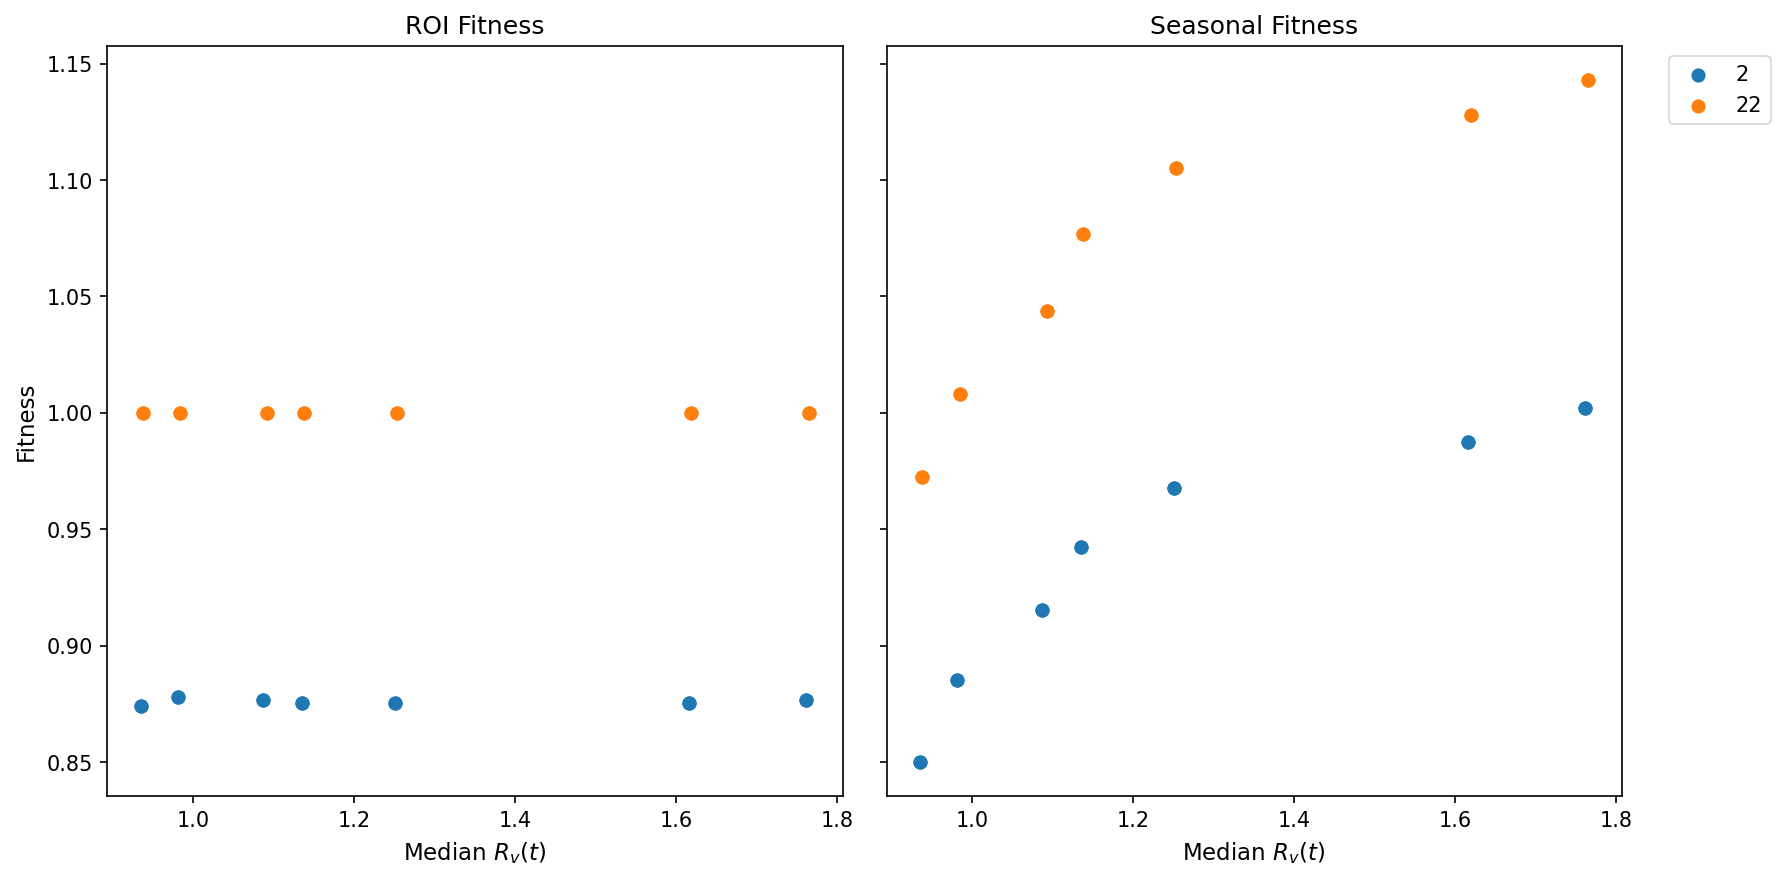

In [24]:
# Create subplots to plot fitness vs median_R and seasonal_fitness vs median_R
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# Plot fitness vs median_R
for variant, df in merged_df.groupby('variant'):
    ax[0].scatter(df['median_R'], df['fitness'], label=variant)
ax[0].set_xlabel('Median $R_v(t)$')
ax[0].set_ylabel('Fitness')
ax[0].set_title('ROI Fitness')
ax[0].legend().remove()


# Plot seasonal_fitness vs median_R
for variant, df in merged_df.groupby('variant'):
    ax[1].scatter(df['median_R'], df['seasonal_fitness'], label=variant)
ax[1].set_title('Seasonal Fitness')
ax[1].set_xlabel('Median $R_v(t)$')
ax[1].legend().remove()

# Add legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout
plt.tight_layout()
plt.show()

## Calculate correlations for each training window

In [25]:
correlation_scores = {
    # Analysis window summary stats
    "analysis_date": [],
    "model": [],
    "location": [],
    "all_variants_flat": [],
    "n_seqs": [],
    "n_cases": [],
    "seq_entropy": [],
    "seq_norm_entropy": [],
    "case_entropy": [],
    "case_norm_entropy": [],
    "max_fitness_sd": [],
    "max_fitness_variant": [],
    "max_Rt_sd": [],
    "max_Rt_variant": [],
    "avg_cv_fitness": [],
    "avg_cv_Rt": [],
    "max_cv": [], # max between avg_cv_fitness and avg_cv_Rt
    "max_cv_source": [], # fitness or Rt
    # Scores
    "ssd": [],
    "combined_flatness_correlation": [],
    "pearson_corr": [],
    "r2": [],
    "pearson_corr_roi": [],
    "r2_roi": [],
    "spearman_corr": [],
    "spearman_corr_roi": []
}
flat_threshold = 0.03
n_paths = len(rt_paths)
i = 0
for rt_path in rt_paths:
    analysis_date = rt_path.split("/")[-1].split("_")[2].split(".")[0]
    model = rt_df["model"].unique()[0]
    location = rt_df["location"].unique()[0]
    window_stats_dict = get_deme_stats(analysis_date, location, build)
    rt_df = pd.read_csv(rt_path, sep="\t")
    rt_df['date'] = pd.to_datetime(rt_df['date'])
    fitness_subset_df = subset_fitness_df(rt_df, fitness_df)
    merged_df = pd.merge(rt_df, fitness_subset_df, on=["date", "variant", "location"], how="inner")

    # Check if all variants are flat
    all_variants_flat = are_all_variants_flat(merged_df, flat_threshold=flat_threshold)

    # Get the max variance for fitness and Rt
    max_fitness_std, max_fitness_variant = get_max_sd(merged_df, column='seasonal_fitness')
    max_Rt_std, max_Rt_variant = get_max_sd(merged_df, column='median_R')

    # Get the average coefficient of variation for fitness and Rt
    avg_cv_fitness = calculate_coefficient_of_variation(merged_df, column='seasonal_fitness')
    avg_cv_Rt = calculate_coefficient_of_variation(merged_df, column='median_R')
    max_cv = max(avg_cv_fitness, avg_cv_Rt)
    if avg_cv_fitness == avg_cv_Rt:
         max_cv_source = "both"
    elif avg_cv_fitness > avg_cv_Rt:
        max_cv_source = "fitness"
    else:
        max_cv_source = "Rt"
    

    # Calculate shape similarity
    avg_ssd = calculate_ssd(merged_df)
    # Calculate Pearson and Spearman correlations 
    pearson_corr = calculate_pearson_correlation(merged_df)
    r2 = pearson_corr ** 2
    spearman_corr = calculate_rank_correlations(merged_df)
    cfcm = calculate_cfcm(merged_df, flat_threshold=flat_threshold)

    # Calculate correlations for fitness column
    pearson_corr_roi = calculate_pearson_correlation(merged_df, fitness_col='fitness')
    r2_roi = pearson_corr_roi ** 2
    spearman_corr_roi = calculate_rank_correlations(merged_df, fitness_col='fitness')
    
    # Store the results in the dictionary
    correlation_scores["analysis_date"].append(analysis_date)
    correlation_scores["model"].append(model)
    correlation_scores["location"].append(location)
    correlation_scores["all_variants_flat"].append(all_variants_flat)
    correlation_scores["n_seqs"].append(window_stats_dict['seq_counts'])
    correlation_scores["n_cases"].append(window_stats_dict['case_counts'])
    correlation_scores["seq_entropy"].append(window_stats_dict['seq_entropy'])
    correlation_scores["seq_norm_entropy"].append(window_stats_dict['seq_norm_entropy'])
    correlation_scores["case_entropy"].append(window_stats_dict['case_entropy'])
    correlation_scores["case_norm_entropy"].append(window_stats_dict['case_norm_entropy'])
    correlation_scores["ssd"].append(avg_ssd),
    correlation_scores["combined_flatness_correlation"].append(cfcm)
    correlation_scores["pearson_corr"].append(pearson_corr)
    correlation_scores["r2"].append(r2)
    correlation_scores["pearson_corr_roi"].append(pearson_corr_roi)
    correlation_scores["r2_roi"].append(r2_roi)
    correlation_scores["spearman_corr"].append(spearman_corr)
    correlation_scores["spearman_corr_roi"].append(spearman_corr_roi)
    correlation_scores["max_fitness_sd"].append(max_fitness_std)
    correlation_scores["max_fitness_variant"].append(max_fitness_variant)
    correlation_scores["max_Rt_sd"].append(max_Rt_std)
    correlation_scores["max_Rt_variant"].append(max_Rt_variant)
    correlation_scores["avg_cv_fitness"].append(avg_cv_fitness)
    correlation_scores["avg_cv_Rt"].append(avg_cv_Rt)
    correlation_scores["max_cv"].append(max_cv)
    correlation_scores["max_cv_source"].append(max_cv_source)
# Convert the dictionary to a DataFrame
correlation_scores_df = pd.DataFrame(correlation_scores)

In [26]:
correlation_scores_df.head()

,analysis_date,model,location,all_variants_flat,n_seqs,n_cases,seq_entropy,seq_norm_entropy,case_entropy,case_norm_entropy,...,max_cv,max_cv_source,ssd,combined_flatness_correlation,pearson_corr,r2,pearson_corr_roi,r2_roi,spearman_corr,spearman_corr_roi
0,2025-04-01,FGA,north,False,19,126,3.036372,0.957869,3.517698,0.950616,...,0.234841,Rt,0.185756,0.907122,0.907122,0.822870,NaN,NaN,1.0,1.0
1,2025-10-01,FGA,north,False,39,265,3.967862,0.951543,4.755958,0.899829,...,0.187399,Rt,0.171490,0.914255,0.914255,0.835862,NaN,NaN,-0.8,-0.8
2,2026-04-01,FGA,north,False,169,1497,3.954842,0.851629,4.276020,0.750121,...,0.179830,Rt,0.221264,0.889368,0.889368,0.790976,0.653924,0.427617,NaN,NaN
3,2026-10-01,FGA,north,False,338,2829,4.721553,0.881289,4.924021,0.863797,...,0.115493,fitness,0.075037,0.962481,0.962481,0.926371,0.797369,0.635798,1.0,1.0
4,2027-04-01,FGA,north,False,2526,21606,4.143048,0.730384,4.132251,0.724900,...,0.117887,fitness,0.307686,0.846157,0.846157,0.715982,-0.072844,0.005306,1.0,1.0


In [27]:
# Save the correlation scores to a TSV file
correlations_path = f"../results/{build}/errors/model_Rt_scores.tsv"
correlation_scores_df.to_csv(correlations_path, sep="\t", index=False)

In [51]:
sns.set_style("white")

## Plot distributions of correlation metrics for model performance

## Taking a look at which training windows have flat variant trajectories

Things to do:
* for each variant, calculate $\frac{\sigma}{\mu}$
* change max standard deviation to average $\frac{\sigma}{\mu}$ for both $R_v(t)$ and $\omega_v(t)$
* subset to low R^2 plot a version where we plot max of the two metrics, and shape by which one was the max

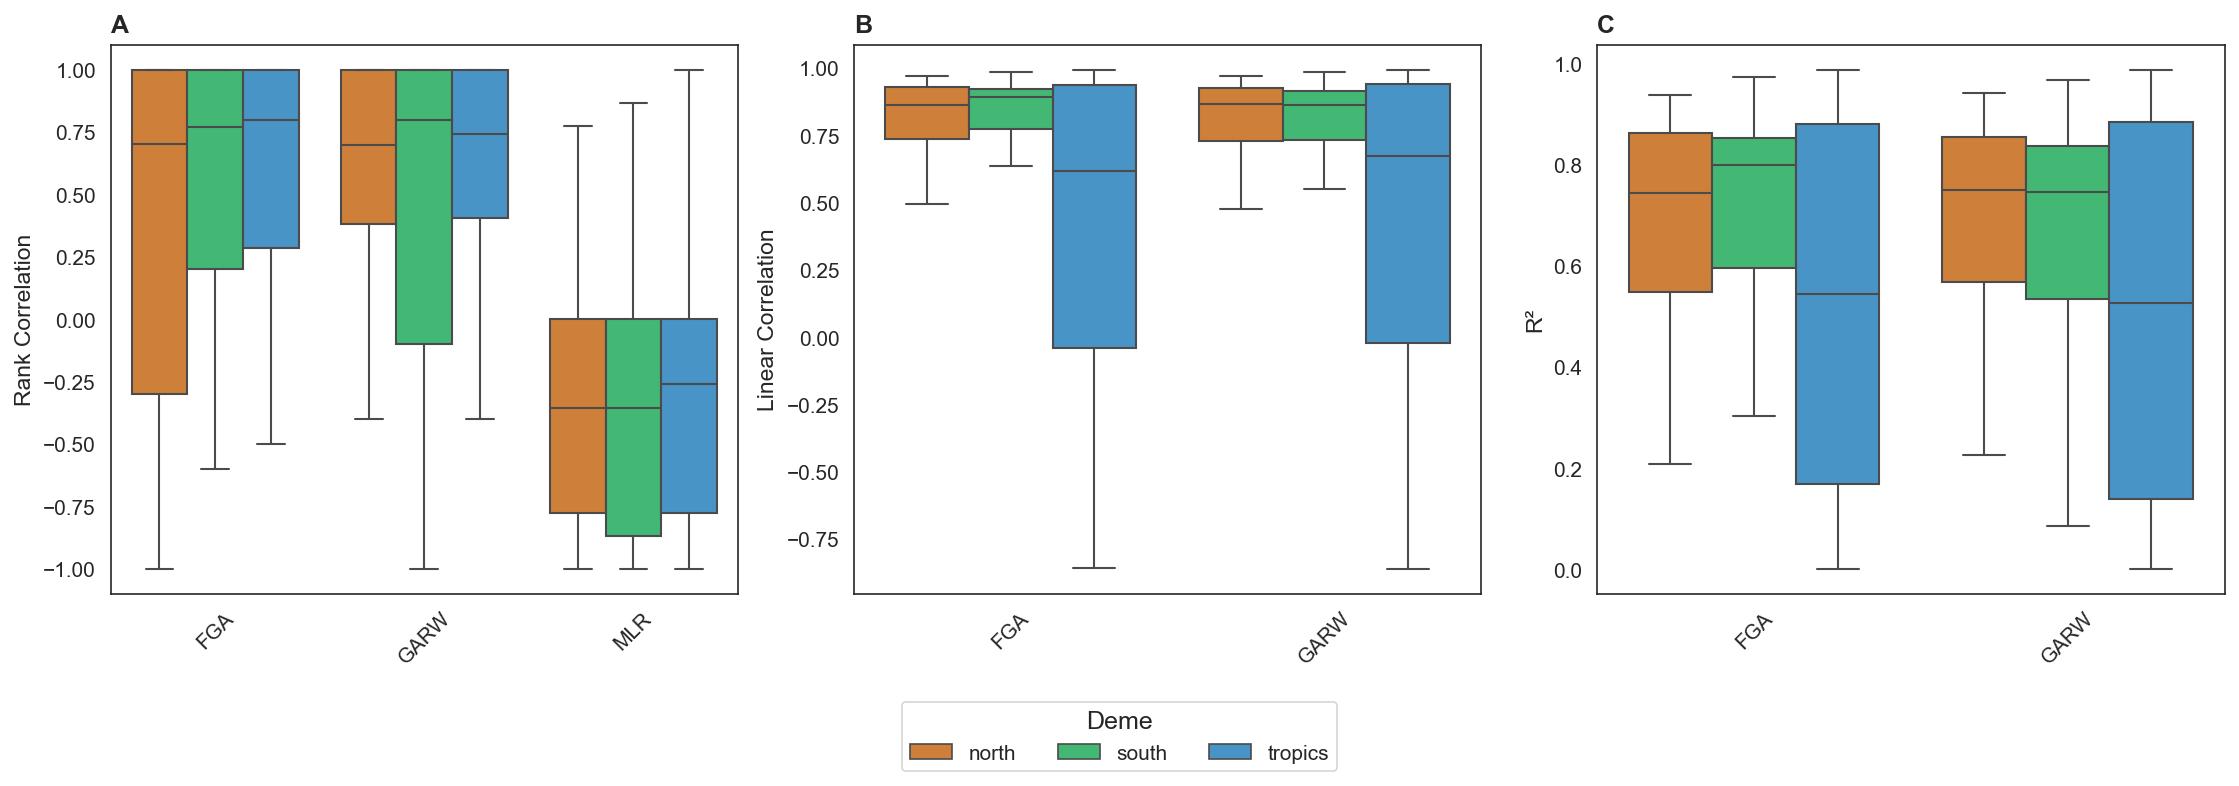

In [53]:
# Create a multi-panel figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# Panel A: Rank correlation (spearman_corr) by model and location
sns.boxplot(x='model', y='spearman_corr', data=correlation_scores_df, hue='location', ax=axes[0], palette=deme_palette, showfliers=False)
axes[0].set_title('A', fontweight='bold', loc='left')
axes[0].set_xlabel('')
axes[0].set_ylabel('Rank Correlation')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend().set_visible(False)

# Panel B: Linear correlation (pearson_corr) by model and location
sns.boxplot(x='model', y='pearson_corr', data=correlation_scores_df.query("model != 'MLR'"), hue='location', ax=axes[1], palette=deme_palette, showfliers=False)
axes[1].set_title('B', fontweight='bold', loc='left')
axes[1].set_xlabel('')
axes[1].set_ylabel('Linear Correlation')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend().set_visible(False)

# Panel C: R-squared (r2) by model and location
sns.boxplot(x='model', y='r2', data=correlation_scores_df.query("model != 'MLR'"), hue='location', ax=axes[2], palette=deme_palette, showfliers=False)
axes[2].set_title('C', fontweight='bold', loc='left')
axes[2].set_xlabel('')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend().set_visible(False)

# Get handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Add the legend at the bottom of the figure
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    title="Deme",
    frameon=True,
    framealpha=0.95,
    edgecolor='lightgray',
    title_fontsize=12
)

# Adjust the bottom margin to make room for the legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)

plt.savefig(figs_path + "fitness_correlation.pdf", dpi=300, bbox_inches='tight')
plt.show()

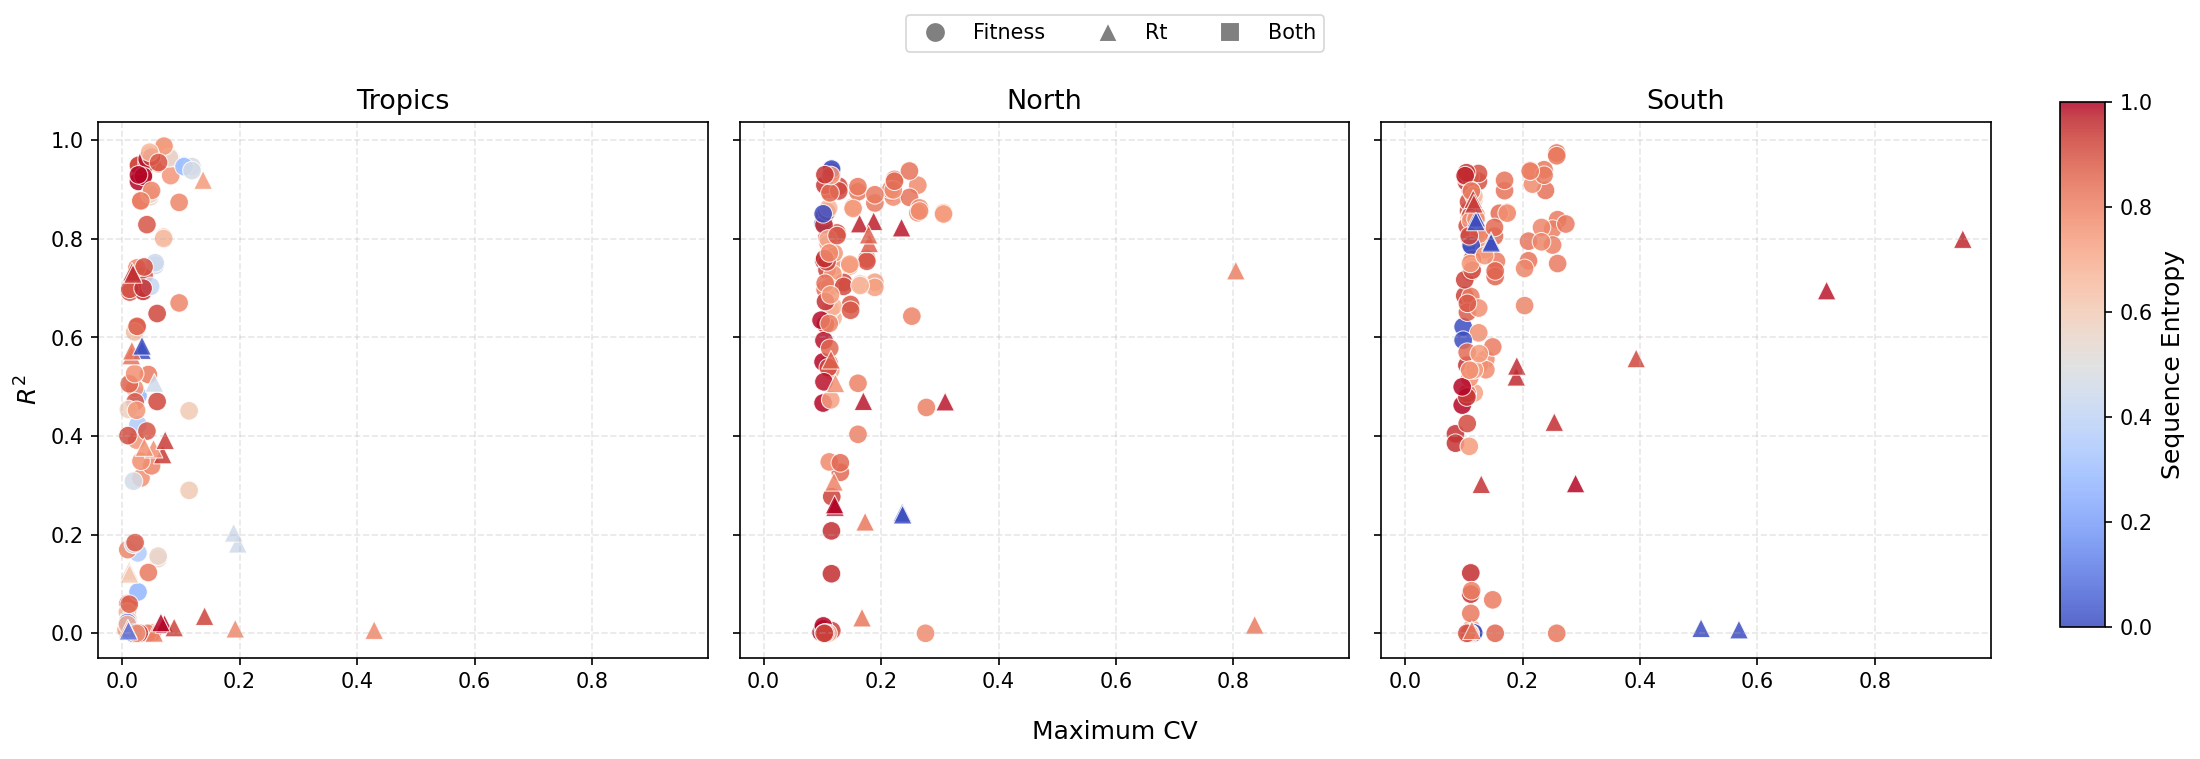

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)
locations = ['tropics', 'north', 'south']

# Define markers for different sources
markers = {'fitness': 'o', 'Rt': '^', 'both': 's'}

for i, loc in enumerate(locations):
    data = correlation_scores_df.query(f"location == '{loc}'")
    
    # Create separate scatter plots for each max_cv_source type
    for source, marker in markers.items():
        source_data = data[data['max_cv_source'] == source]
        scatter = axes[i].scatter(
            x='max_cv',
            y='r2',
            data=source_data,
            c=source_data['seq_norm_entropy'],
            cmap='coolwarm',
            s=80,                   
            alpha=0.85,
            marker=marker,
            edgecolor='white',     
            linewidth=0.5          
        )
    
    # Set titles and labels
    axes[i].set_title(f"{loc.capitalize()}", fontsize=13, fontweight='medium')
    axes[i].grid(True, linestyle='--', alpha=0.3)
    
    # Only set ylabel for the first subplot
    if i == 0:
        axes[i].set_ylabel(r"$R^2$", fontsize=12)
    
    # Hide x-axis labels for all subplots
    axes[i].set_xlabel("")

# Add a common x-axis label in the middle
fig.text(0.5, 0.01, r"Maximum CV", ha='center', va='center', fontsize=12)

# Add colorbar to the right of the last plot
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Sequence Entropy', fontsize=12)

# Add legend for markers
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor='gray', markersize=10, label='Fitness'),
                  plt.Line2D([0], [0], marker='^', color='w', 
                              markerfacecolor='gray', markersize=10, label='Rt'),
                  plt.Line2D([0], [0], marker='s', color='w', 
                              markerfacecolor='gray', markersize=10, label='Both')]

# Place the legend at the top of the figure
fig.legend(handles=legend_elements, loc='upper center', 
           bbox_to_anchor=(0.5, 0.98), ncol=3)

# Adjust layout to accommodate the colorbar on the right and legend at the top
plt.subplots_adjust(right=0.9, top=0.85)
plt.tight_layout(rect=[0, 0.03, 0.9, 0.9])  # Adjust the rect to leave room for the x-axis label

plt.show()

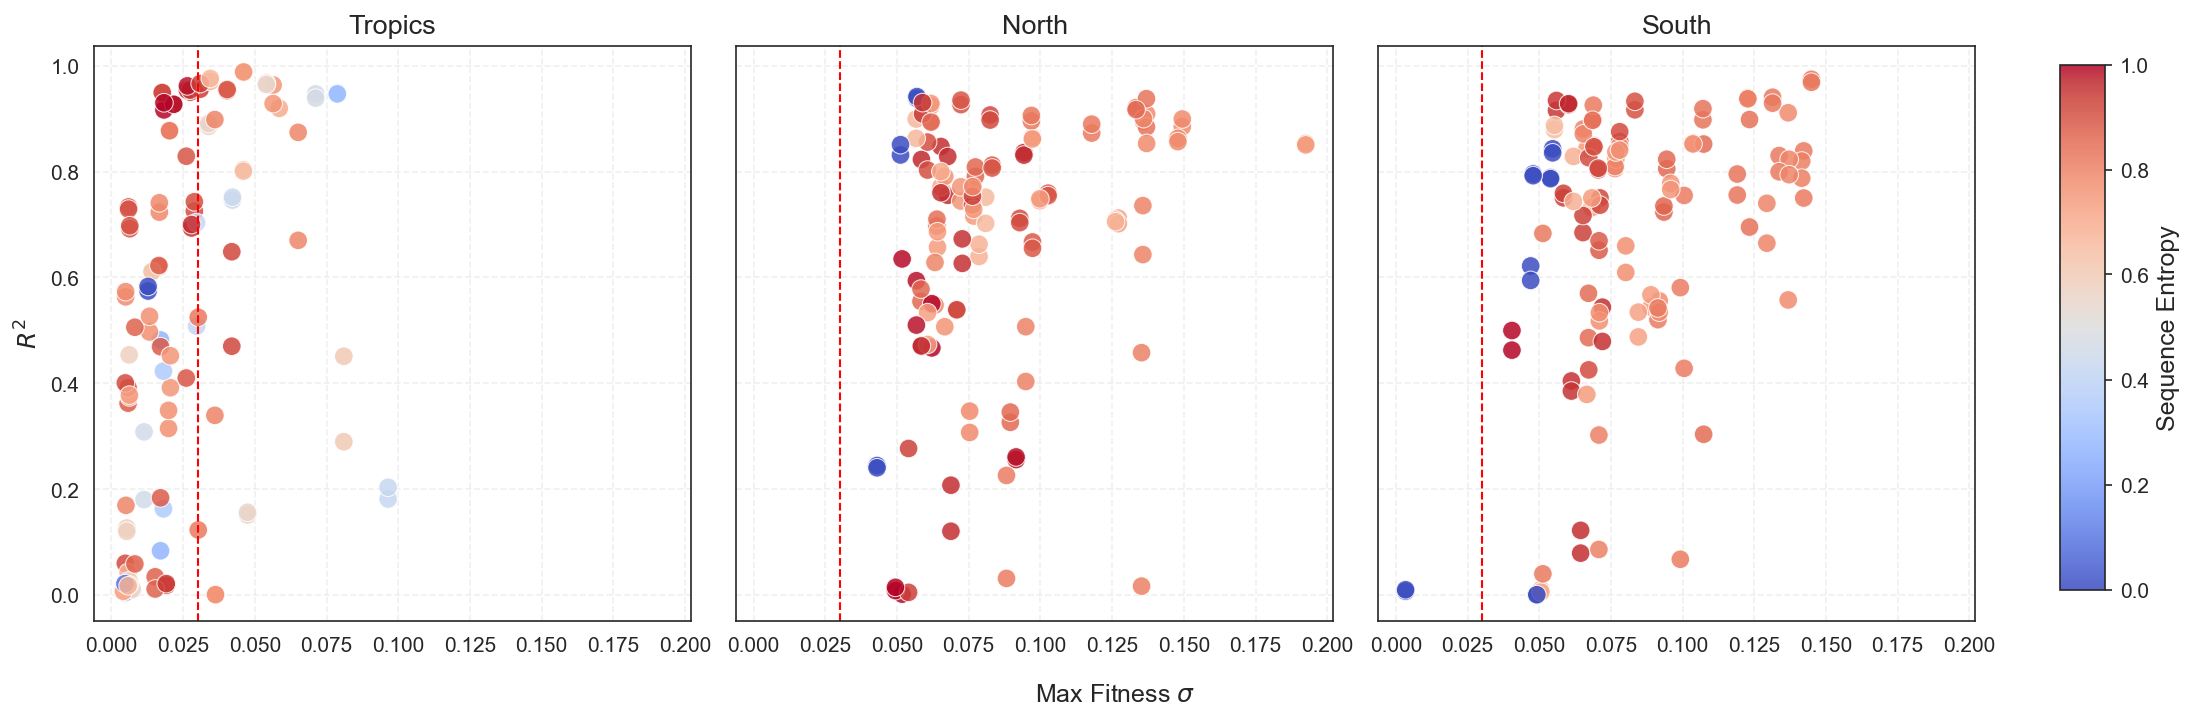

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)
locations = ['tropics', 'north', 'south']

for i, loc in enumerate(locations):
    data = correlation_scores_df.query(f"location == '{loc}'")
    
    # Create a scatter plot with points colored by seq_entropy instead of case_entropy
    scatter = axes[i].scatter(
        x='max_fitness_sd',
        y='r2',
        data=data,
        c=data['seq_norm_entropy'],  # Using seq_entropy for coloring
        cmap='coolwarm',
        s=80,                   
        alpha=0.85,            
        edgecolor='white',     
        linewidth=0.5          
    )
    
    # Add dashed vertical line at flatness threshold
    axes[i].axvline(x=flat_threshold, color='red', linestyle='--', linewidth=1, label='Flatness Threshold')
    
    # Set titles and labels
    axes[i].set_title(f"{loc.capitalize()}", fontsize=13, fontweight='medium')
    axes[i].grid(True, linestyle='--', alpha=0.3)
    
    # Only set ylabel for the first subplot
    if i == 0:
        axes[i].set_ylabel(r"$R^2$", fontsize=12)
    
    # Hide x-axis labels for all subplots
    axes[i].set_xlabel("")

# Add a common x-axis label in the middle
fig.text(0.5, 0.01, r"Max Fitness $\sigma$", ha='center', va='center', fontsize=12)

# Add colorbar to the right of the last plot
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Sequence Entropy', fontsize=12)

# Adjust layout to accommodate the colorbar on the right
plt.subplots_adjust(right=0.9)
plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])  # Adjust the rect to leave room for the x-axis label

plt.show()

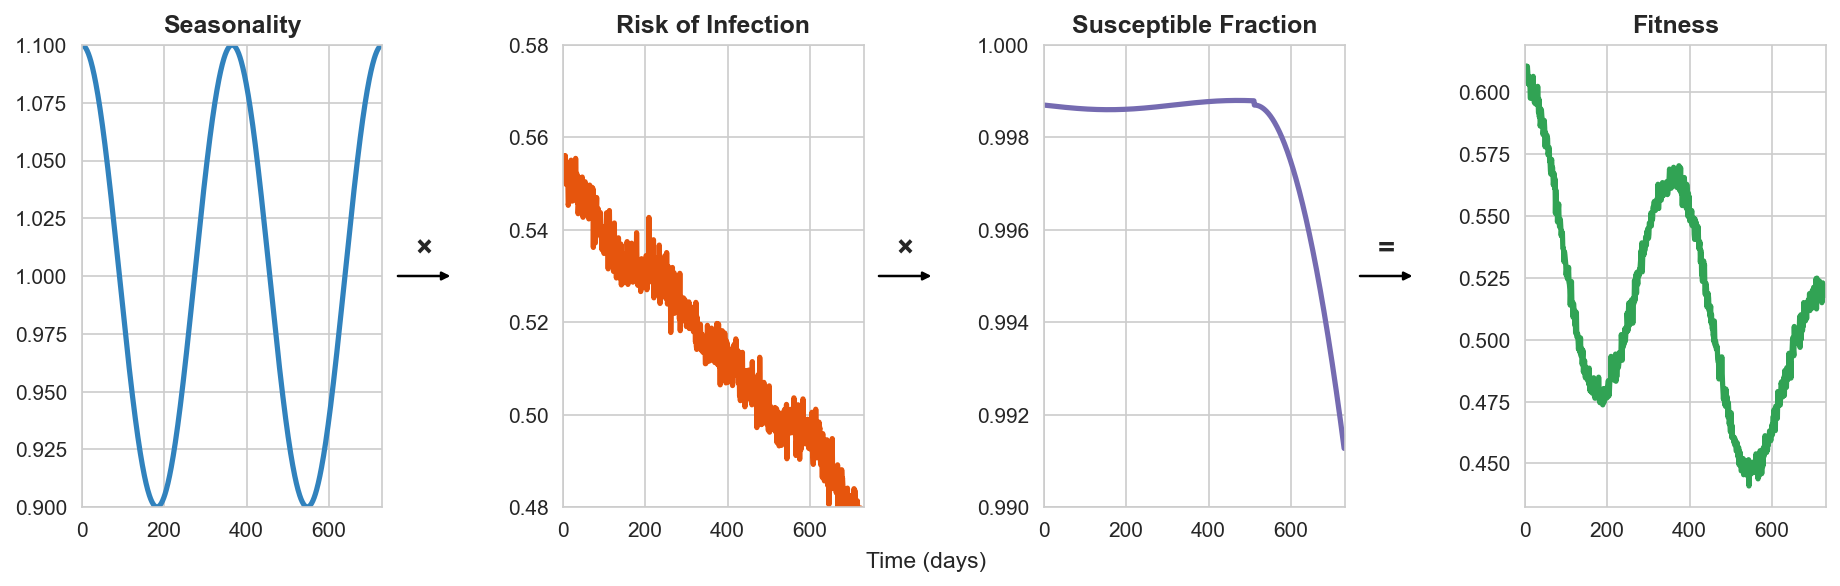

In [54]:
# Set the style
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 9})

# Generate mock data
days = 365 * 2  # Two years of data
time = np.arange(days)

# Seasonality - cosine wave for North hemisphere
seasonality_north = 1 + 0.1 * np.cos(2 * np.pi * time / 365)

# Risk of infection - decreasing trend with jagged pattern
base_risk = 0.55 - (time / days) * 0.07
# Add noise to create jagged appearance
np.random.seed(42)  # For reproducibility
noise = np.random.normal(0, 0.003, size=len(time))
# Add small oscillations with different frequencies
oscillations = 0.002 * np.sin(time / 30) + 0.0015 * np.cos(time / 45)
risk_of_infection = base_risk + noise + oscillations

# Fraction of susceptible population - similar pattern to the provided image
# Start with high values near 0.999 and gradually decrease more rapidly at the end
susceptible_fraction = np.zeros_like(time, dtype=float)
for i in range(len(time)):
    if i < len(time) * 0.7:  # First 70% of the time period
        susceptible_fraction[i] = 0.9987 - 0.0001 * np.sin(i / 100)
    else:  # Last 30% - more rapid decrease
        position = (i - len(time) * 0.7) / (len(time) * 0.3)
        susceptible_fraction[i] = 0.9987 - 0.0075 * position**2

# Combined seasonal fitness (product of all three components)
seasonal_fitness = seasonality_north * risk_of_infection * susceptible_fraction

# Create figure with subplots - HORIZONTAL LAYOUT (1x4)
fig = plt.figure(figsize=(15, 4))
# Increase the wspace parameter for even more space between subplots
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 1], wspace=0.6)

# Subplot 1: Seasonality
ax1 = plt.subplot(gs[0])
sns.lineplot(x=time, y=seasonality_north, color='#3182bd', linewidth=2.5, ax=ax1)
ax1.set_title('Seasonality', fontweight='bold')
ax1.set_xlim(0, days)
ax1.set_ylim(0.9, 1.1)
# Don't set individual x-axis labels since we'll add a shared one

# Subplot 2: Risk of Infection
ax2 = plt.subplot(gs[1])
sns.lineplot(x=time, y=risk_of_infection, color='#e6550d', linewidth=2.5, ax=ax2)
ax2.set_title('Risk of Infection', fontweight='bold')
ax2.set_xlim(0, days)
ax2.set_ylim(0.48, 0.58)
# Don't set individual x-axis labels since we'll add a shared one

# Subplot 3: Susceptible Fraction (previously missing)
ax3 = plt.subplot(gs[2])
sns.lineplot(x=time, y=susceptible_fraction, color='#756bb1', linewidth=2.5, ax=ax3)
ax3.set_title('Susceptible Fraction', fontweight='bold')
ax3.set_xlim(0, days)
ax3.set_ylim(0.99, 1.0)
# Don't set individual x-axis labels since we'll add a shared one

# Subplot 4: Combined Fitness
ax4 = plt.subplot(gs[3])
sns.lineplot(x=time, y=seasonal_fitness, color='#31a354', linewidth=2.5, ax=ax4)
ax4.set_title('Fitness', fontweight='bold')
ax4.set_xlim(0, days)
y_min, y_max = min(seasonal_fitness), max(seasonal_fitness)
padding = (y_max - y_min) * 0.05
ax4.set_ylim(y_min - padding, y_max + padding)

# Adjust layout first to make sure positions are updated
plt.tight_layout()

# Get the figure-normalized coordinates of the axes after tight_layout
ax1_pos = ax1.get_position()
ax2_pos = ax2.get_position()
ax3_pos = ax3.get_position()
ax4_pos = ax4.get_position()

# Calculate vertical offset for the symbols (above the arrow)
vertical_offset = 0.045  # Increased vertical offset for symbols

# Define horizontal offsets for arrows
# Arrow between subplot 1 and 2
left_space1 = ax2_pos.x0 - ax1_pos.x1  # Space between plot 1 and 2
arrow1_start = ax1_pos.x1 + 0.005  # Almost at edge of plot 1
arrow1_end = ax2_pos.x0 - left_space1*0.6  # End at 40% of the way to plot 2

# Arrow between subplot 2 and 3
left_space2 = ax3_pos.x0 - ax2_pos.x1  # Space between plot 2 and 3
arrow2_start = ax2_pos.x1 + 0.005  # Almost at edge of plot 2
arrow2_end = ax3_pos.x0 - left_space2*0.6  # End at 40% of the way to plot 3

# Arrow between subplot 3 and 4
left_space3 = ax4_pos.x0 - ax3_pos.x1  # Space between plot 3 and 4
arrow3_start = ax3_pos.x1 + 0.005  # Almost at edge of plot 3
arrow3_end = ax4_pos.x0 - left_space3*0.6  # End at 40% of the way to plot 4

# Calculate midpoint position for the text (horizontally aligned with arrows)
text1_x = arrow1_start + (arrow1_end - arrow1_start) / 2
text2_x = arrow2_start + (arrow2_end - arrow2_start) / 2
text3_x = arrow3_start + (arrow3_end - arrow3_start) / 2

# Add arrows
arrow1 = FancyArrowPatch(
    (arrow1_start, ax1_pos.y0 + ax1_pos.height/2),
    (arrow1_end, ax2_pos.y0 + ax2_pos.height/2),
    transform=fig.transFigure,
    arrowstyle='-|>',
    color='black',
    linewidth=1.2,
    mutation_scale=8  # Smaller arrowheads
)
fig.add_artist(arrow1)

arrow2 = FancyArrowPatch(
    (arrow2_start, ax2_pos.y0 + ax2_pos.height/2),
    (arrow2_end, ax3_pos.y0 + ax3_pos.height/2),
    transform=fig.transFigure,
    arrowstyle='-|>',
    color='black',
    linewidth=1.2,
    mutation_scale=8  # Smaller arrowheads
)
fig.add_artist(arrow2)

arrow3 = FancyArrowPatch(
    (arrow3_start, ax3_pos.y0 + ax3_pos.height/2),
    (arrow3_end, ax4_pos.y0 + ax4_pos.height/2),
    transform=fig.transFigure,
    arrowstyle='-|>',
    color='black',
    linewidth=1.2,
    mutation_scale=8  # Smaller arrowheads
)
fig.add_artist(arrow3)

# Position multiplication and equals symbols directly above the arrows
fig.text(text1_x, ax1_pos.y0 + ax1_pos.height/2 + vertical_offset, 
        "×", fontsize=14, fontweight='bold', ha='center', va='center')
fig.text(text2_x, ax2_pos.y0 + ax2_pos.height/2 + vertical_offset, 
        "×", fontsize=14, fontweight='bold', ha='center', va='center')
fig.text(text3_x, ax3_pos.y0 + ax3_pos.height/2 + vertical_offset, 
        "=", fontsize=14, fontweight='bold', ha='center', va='center')

# Add a shared x-axis label at the bottom of the figure
fig.text(0.5, 0.02, 'Time (days)', ha='center', va='center', fontsize=11)

plt.savefig(figs_path + 'seasonal_fitness_schematic.pdf', dpi=300, bbox_inches='tight')
plt.show()